# Project A

## By Anish Gole

## Dataset - Titanic

## Algorithm - Logistic Regression

### 1. Problem Statement

#### The sinking of the RMS Titanic is one of the most infamous shipwrecks in history. On April 15, 1912, during her maiden voyage, the Titanic sank after colliding with an iceberg, killing numerous passengers and crew. This sensational tragedy shocked the international community and led to better safety regulations for ships.
#### One of the reasons that the shipwreck led to such loss of life was that there were not enough lifeboats for the passengers and crew. Although there was some element of luck involved in surviving the sinking, some groups of people were more likely to survive than others, such as women, children, and the upper-class.
#### In this, we ask you to complete the analysis of what sorts of people were likely to survive. In particular, we ask you to apply the tools of machine learning to predict which passengers survived the tragedy.

### 2. Import Required Libraries and Data

In [1]:
import numpy as np # Numerical operation
import pandas as pd # Working with datasets
import matplotlib.pyplot as plt # Plotting graphs
import seaborn as sns # Plotting high level graphs

# Display plots inline
%matplotlib inline

In [2]:
Titanic = pd.read_csv('Titanic_Train.csv') # Upload dataset CSV

In [3]:
Titanic.shape # Check number of rows and column

(891, 12)

In [4]:
Titanic.info() # Check datatype

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
PassengerId    891 non-null int64
Survived       891 non-null int64
Pclass         891 non-null int64
Name           891 non-null object
Sex            891 non-null object
Age            714 non-null float64
SibSp          891 non-null int64
Parch          891 non-null int64
Ticket         891 non-null object
Fare           891 non-null float64
Cabin          204 non-null object
Embarked       889 non-null object
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
Titanic.head() # View top 5 records

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
Titanic.tail() # View bottom 5 records

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [7]:
Titanic.describe() # Describe basic statistics of numerical variables

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### 3. Exploratory Data Analysis

In [8]:
Titanic.info() # Check for missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
PassengerId    891 non-null int64
Survived       891 non-null int64
Pclass         891 non-null int64
Name           891 non-null object
Sex            891 non-null object
Age            714 non-null float64
SibSp          891 non-null int64
Parch          891 non-null int64
Ticket         891 non-null object
Fare           891 non-null float64
Cabin          204 non-null object
Embarked       889 non-null object
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


<AxesSubplot:>

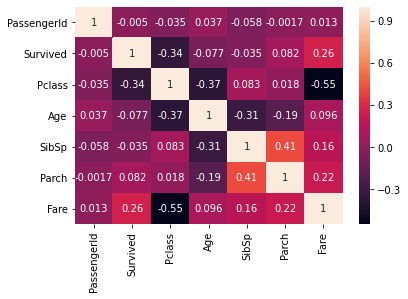

In [9]:
sns.heatmap(Titanic.corr(), annot= True)

In [10]:
Titanic.corr()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


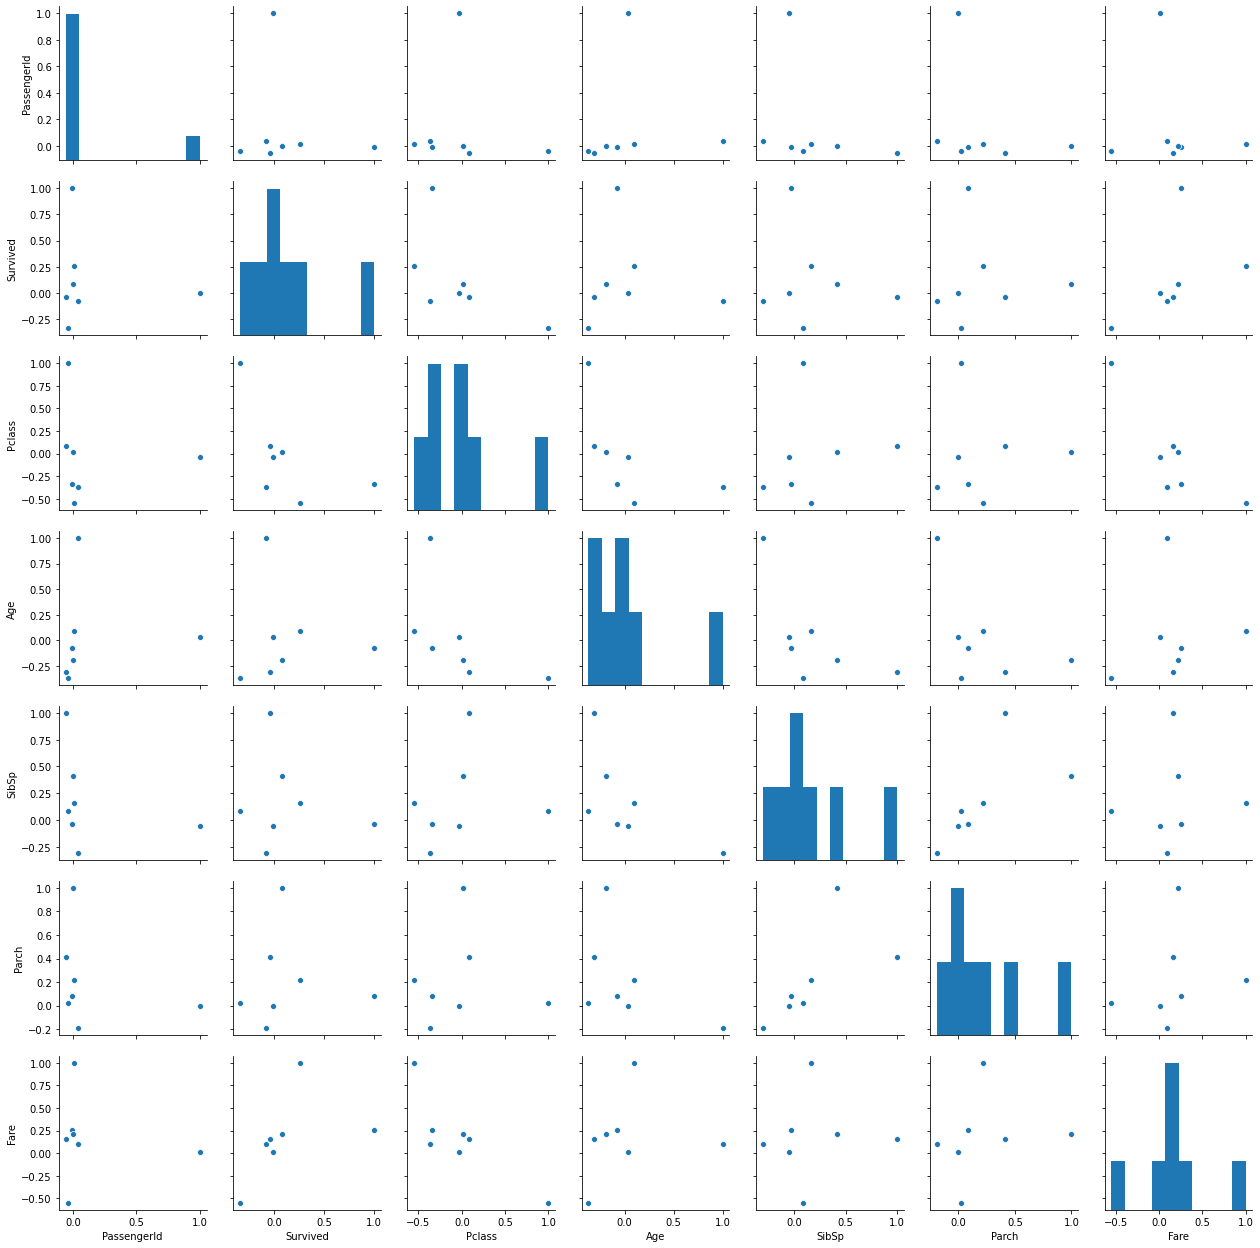

In [11]:
sns.pairplot(Titanic.corr())

In [12]:
Titanic.isnull().head() # Check top 5 for null values

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False


In [13]:
Titanic.isnull().tail() # Check bottom 5 for null values

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False
890,False,False,False,False,False,False,False,False,False,False,True,False


<AxesSubplot:>

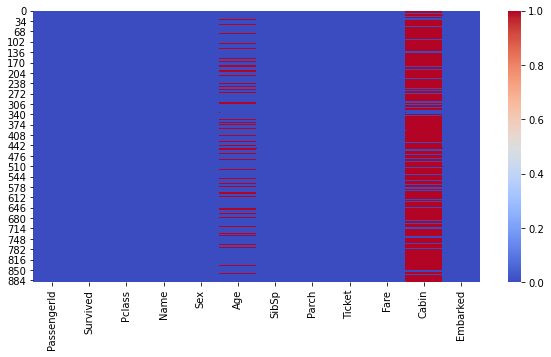

In [14]:
plt.figure(figsize=(10,5))
sns.heatmap(Titanic.isnull(), cmap = 'coolwarm') # Plot heatmap to view null values

#### Basis the heatmap - we have lot of missing values for Cabin, some missing values for Age and 2 values are missing for Embarked info

<AxesSubplot:xlabel='count', ylabel='Survived'>

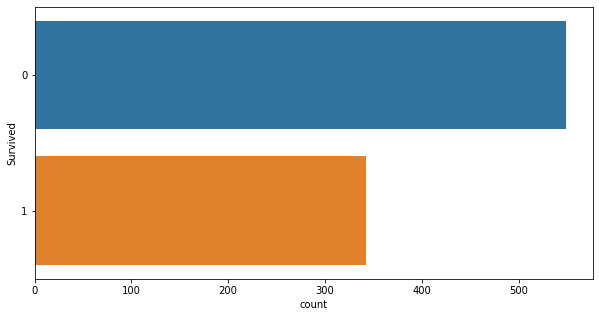

In [15]:
plt.figure(figsize=(10,5))
sns.countplot(y=Titanic['Survived']) # Plot countplot to compare survived Vs non survived passengers

<AxesSubplot:xlabel='count', ylabel='Survived'>

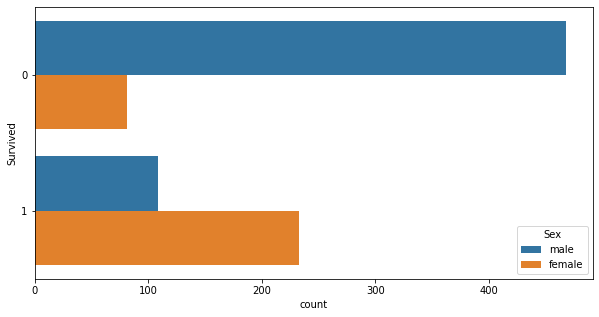

In [16]:
# Plot countplot to compare survived Vs non survived passengers by gender
plt.figure(figsize=(10,5))
sns.countplot(y=Titanic['Survived'], hue = Titanic['Sex'])

#### Basis countcplot we can see that more men did not survive compared to women. While almost double count of men, women survived as per the data.

<AxesSubplot:xlabel='count', ylabel='Survived'>

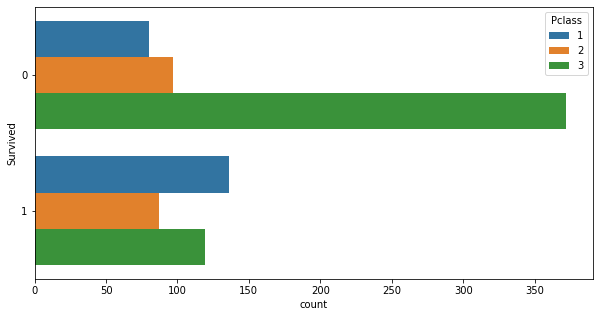

In [17]:
# Plot countplot to compare survived Vs non survived passengers by class
plt.figure(figsize=(10,5))
sns.countplot(y=Titanic['Survived'], hue = Titanic['Pclass'])

#### With this we can see that people who did not survive were majority from 3rd class and who survived were primarily from 1st class.

<AxesSubplot:xlabel='Age'>

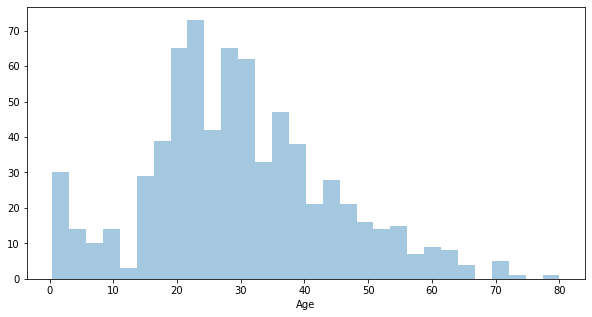

In [18]:
plt.figure(figsize=(10,5))
sns.distplot(Titanic['Age'].dropna(), bins = 30, kde = False) # Plot histogram to understand age group of passengers

<AxesSubplot:xlabel='SibSp', ylabel='count'>

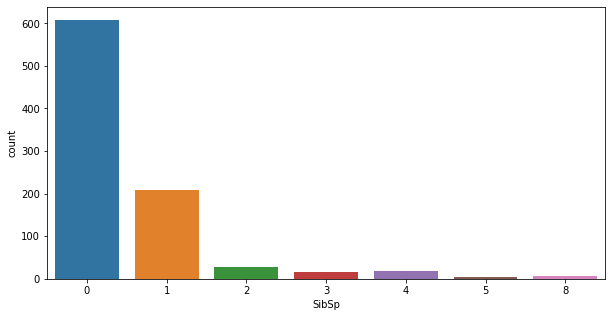

In [19]:
plt.figure(figsize=(10,5))
sns.countplot(Titanic['SibSp']) # Plot countplot to understand the no. of siblings/spouses on the Titanic

<AxesSubplot:xlabel='Parch', ylabel='count'>

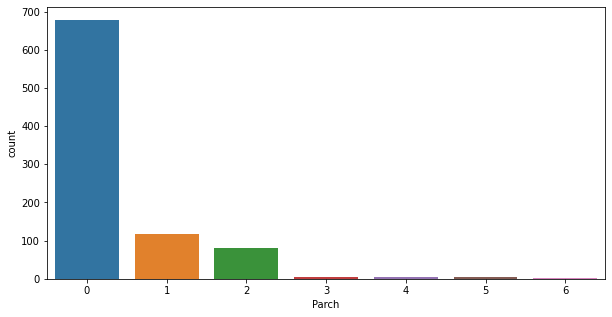

In [20]:
plt.figure(figsize=(10,5))
sns.countplot(Titanic['Parch']) # Plot countplot to understand the no. of parents/children on the Titanic

<AxesSubplot:xlabel='Fare'>

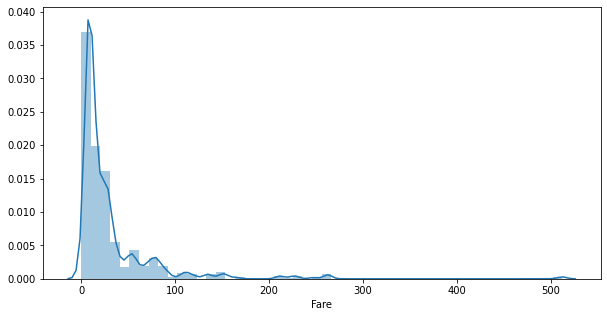

In [21]:
plt.figure(figsize=(10,5))
sns.distplot(Titanic['Fare'], bins = 50) # Plot histogram to understand fare

### 4. Clean Data

#### Checking missing values in the dataset

In [22]:
Titanic.info() # Check missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
PassengerId    891 non-null int64
Survived       891 non-null int64
Pclass         891 non-null int64
Name           891 non-null object
Sex            891 non-null object
Age            714 non-null float64
SibSp          891 non-null int64
Parch          891 non-null int64
Ticket         891 non-null object
Fare           891 non-null float64
Cabin          204 non-null object
Embarked       889 non-null object
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


<AxesSubplot:>

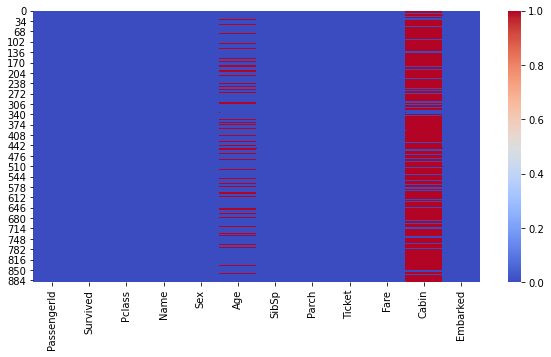

In [23]:
plt.figure(figsize=(10,5))
sns.heatmap(Titanic.isnull(), cmap = 'coolwarm') # Plot heatmap to view null values

#### Checking outliers in Age by Pclass

<AxesSubplot:xlabel='Pclass', ylabel='Age'>

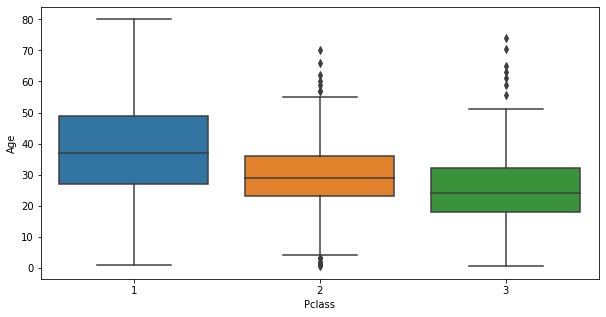

In [24]:
plt.figure(figsize=(10,5))
sns.boxplot(x = Titanic['Pclass'], y = Titanic['Age']) # Plot the boxplot of Age by Pclass to view outliers

#### Taking Mean of Age by Pclass and updating the missing values in Age column by Mean of Age by Pclass

In [25]:
Titanic.groupby(Titanic['Pclass']).mean()['Age'].round() # Check Mean of Age by Pclass

Pclass
1    38.0
2    30.0
3    25.0
Name: Age, dtype: float64

In [26]:
# Fill missing values by Mean of Age by Pclass
Titanic.loc[Titanic['Pclass']==1, ['Age']] = Titanic.loc[Titanic['Pclass']==1, ['Age']].fillna(value = Titanic.groupby(['Pclass']).mean()['Age'].round().loc[1])
Titanic.loc[Titanic['Pclass']==2, ['Age']] = Titanic.loc[Titanic['Pclass']==2, ['Age']].fillna(value = Titanic.groupby(['Pclass']).mean()['Age'].round().loc[2])
Titanic.loc[Titanic['Pclass']==3, ['Age']] = Titanic.loc[Titanic['Pclass']==3, ['Age']].fillna(value = Titanic.groupby(['Pclass']).mean()['Age'].round().loc[3])
Titanic.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,25.0,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [27]:
#Mean_Pclass_1 = Titanic.groupby(Titanic['Pclass']).mean()['Age'].round().loc[1]
#Mean_Pclass_2 = Titanic.groupby(Titanic['Pclass']).mean()['Age'].round().loc[2]
#Mean_Pclass_3 = Titanic.groupby(Titanic['Pclass']).mean()['Age'].round().loc[3]

In [28]:
#Titanic.loc[Titanic['Pclass']==1, 'Age'] = Titanic.loc[Titanic['Pclass']==1, 'Age'].fillna(value = Mean_Pclass_1)
#Titanic.loc

#### Dropping column Cabin as there are too many missing entries

In [29]:
Titanic.drop('Cabin', axis = 1, inplace=True) # Drop column Cabin as there are too many missing entries

In [30]:
Titanic.dropna(inplace = True)

#### Converting categorical columns to dummy variables

In [31]:
Sex = pd.get_dummies(Titanic['Sex'], drop_first = True) # Converting Sex column

In [32]:
Embarked = pd.get_dummies(Titanic['Embarked'], drop_first = True) # converting Embarked column

In [33]:
Titanic = pd.concat([Titanic, Sex, Embarked], axis = 1) # Concatenating Sex & Embarked

In [34]:
 # dropping other categorical columns
Titanic.drop(['PassengerId', 'Name', 'Sex', 'Ticket', 'Embarked'], axis = 1, inplace=True)

### 5. Train and Build Classifier

In [35]:
X = Titanic.drop('Survived', axis = 1) # Drop column Survived while assigning variables to X

In [36]:
y = Titanic['Survived'] # Assign Srvived column to y

In [37]:
X.head() # View top 5 records in X

,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,3,22.0,1,0,7.2500,1,0,1
1,1,38.0,1,0,71.2833,0,0,0
2,3,26.0,0,0,7.9250,0,0,1
3,1,35.0,1,0,53.1000,0,0,1
4,3,35.0,0,0,8.0500,1,0,1


In [38]:
y.head() # View top 5 in y

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [39]:
from sklearn.model_selection import train_test_split # Import train and test split data function

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [41]:
from sklearn.linear_model import LogisticRegression # Import function Logistic Regression

In [42]:
LogModel = LogisticRegression() # Assign Logistic Regression to logmodel

In [43]:
# Fit the data we splitted earlier through train_test_split function in the LogModel Logistic Regression function
LogModel.fit(X_train, y_train) 

C:\Users\Mahesh S Valanju\Anaconda3\lib\site-packages\sklearn\linear_model\logistic.py:432: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)


LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='warn', n_jobs=None, penalty='l2',
                   random_state=None, solver='warn', tol=0.0001, verbose=0,
                   warm_start=False)

In [44]:
LogModel.score(X_train, y_train) # Check the scor of the trained model basis train dataset

0.7877813504823151

In [45]:
LogModel.score(X_test, y_test)  # Check the scor of the trained model basis test dataset

0.8277153558052435

In [46]:
y_pred = LogModel.predict(X_train) # Apply log model to predict y

In [47]:
y_pred # View predicted y

array([0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1,
       1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,

In [48]:
from sklearn.metrics import confusion_matrix # Import Confusion Matrix function

In [49]:
confusion_matrix(y_train, y_pred) # View confusion matrix

array([[332,  51],
       [ 81, 158]], dtype=int64)

### 6. Making Predections

#### For testing the model and my reference purpose, I have taken testing dataset which was shared during live lectures by trainer. If this part is not required then you can ignore.

In [50]:
# Upload your .csv file with data for which you would like to predict survival
TitanicTest = pd.read_csv('Titanic_Test.csv') # Upload dataset CSV

In [51]:
# Fill missing values by Mean of Age by Pclass
TitanicTest.loc[TitanicTest['Pclass']==1, ['Age']] = TitanicTest.loc[TitanicTest['Pclass']==1, ['Age']].fillna(value = TitanicTest.groupby(['Pclass']).mean()['Age'].round().loc[1])
TitanicTest.loc[TitanicTest['Pclass']==2, ['Age']] = TitanicTest.loc[TitanicTest['Pclass']==2, ['Age']].fillna(value = TitanicTest.groupby(['Pclass']).mean()['Age'].round().loc[2])
TitanicTest.loc[TitanicTest['Pclass']==3, ['Age']] = TitanicTest.loc[TitanicTest['Pclass']==3, ['Age']].fillna(value = TitanicTest.groupby(['Pclass']).mean()['Age'].round().loc[3])

In [52]:
# Convert categorical columns to dummy variables
Sex = pd.get_dummies(TitanicTest['Sex'], drop_first = True) # Converting Sex column
Embarked = pd.get_dummies(TitanicTest['Embarked'], drop_first = True) # converting Embarked column
TitanicTest = pd.concat([TitanicTest, Sex, Embarked], axis = 1) # Concatenating Sex & Embarked
TitanicTest.drop('Cabin', axis = 1, inplace=True) # Drop column Cabin as there are too many missing entries

 # dropping other categorical columns
TitanicTest.drop(['Name', 'Sex', 'Ticket', 'Embarked'], axis = 1, inplace = True)

In [53]:
TestData = TitanicTest.drop('PassengerId', axis = 1) # Assigning Titanic test data to TestData

In [54]:
Predictions = LogModel.predict(TestData) # Assigning model created from train data to predict test data

In [55]:
# Preparing output format
Final_Predictions = pd.DataFrame({'PassengerId':TitanicTest['PassengerId'], 'Survived':Predictions})

In [56]:
Final_Predictions.head() # View predicted output

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
